In [1]:
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
from tqdm.notebook import tqdm  # Import tqdm specifically optimized for Jupyter

# 1. Load environment variables from your .env file
load_dotenv()
print("Connecting to PostgreSQL...")

# 2. Securely fetch the credentials
db_user = os.getenv("DB_USER")
db_password = os.getenv("DB_PASSWORD")
db_host = os.getenv("DB_HOST")
db_port = os.getenv("DB_PORT")
db_name = os.getenv("DB_NAME")

# 3. Construct the database URL and create the engine
db_url = f"postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
engine = create_engine(db_url)

# 4. Ask PostgreSQL exactly how many rows exist so the progress bar knows what 100% is
count_query = "SELECT COUNT(*) FROM public.model_features_v07;"
total_rows = pd.read_sql(count_query, engine).iloc[0, 0]

# 5. Fetch the data in chunks and update the progress bar
query = "SELECT * FROM public.model_features_v07;"
chunksize = 100000 
chunks = [] # We will store our data chunks here temporarily

print(f"Fetching {total_rows:,} engineered features from local database...")

# Create the progress bar
with tqdm(total=total_rows, desc="Downloading Data") as pbar:
    # Read the data in chunks
    for chunk in pd.read_sql(query, engine, chunksize=chunksize):
        chunks.append(chunk)      # Save the chunk
        pbar.update(len(chunk))   # Move the progress bar forward

# 6. Stitch all the chunks together into one massive DataFrame
df = pd.concat(chunks, ignore_index=True)

print(f"Success! Loaded {len(df):,} rows into local memory.")
display(df.head())

Connecting to PostgreSQL...
Fetching 5,732,926 engineered features from local database...


Success! Loaded 5,732,926 rows into local memory.


,MONTH,DAY,DAY_OF_WEEK,AIRLINE_ID,ORIGIN_AIRPORT_ID,DESTINATION_AIRPORT_ID,DISTANCE,SCHEDULED_DEPARTURE_TIME,DEPARTURE_HOUR,ARRIVAL_HOUR,...,ORIGIN_CLOUD_COVER_LOW,DEST_PRECIPITATION,DEST_SNOWFALL,DEST_WIND_SPEED,DEST_WIND_GUSTS,DEST_CLOUD_COVER_LOW,PREVIOUS_FLIGHT_DELAYED,ORIGIN_HOURLY_AIRPORT_TRAFFIC,DEST_HOURLY_AIRPORT_TRAFFIC,IS_DELAYED
0,2,10,2,2,204.0,295.0,1068,2105,21,23,...,3,0.0,0.0,7.4,12.6,0,0,24,4,0
1,7,7,2,2,87.0,199.0,469,850,8,10,...,6,0.0,0.0,29.5,50.0,6,0,53,2,0
2,1,23,5,2,204.0,295.0,1068,2105,21,23,...,29,0.0,0.0,5.4,13.0,2,0,25,4,0
3,9,23,3,2,87.0,199.0,469,850,8,10,...,0,0.0,0.0,10.1,19.4,29,0,45,2,1
4,5,20,3,2,87.0,152.0,224,1205,12,13,...,2,0.2,0.0,6.6,30.6,29,0,58,45,1


In [3]:
from sklearn.model_selection import train_test_split
import cupy as cp

print("Starting preprocessing...")

# 1. Drop columns we don't need for the predictive model
# relying on the ROUTE_HISTORIC_DELAY feature instead.
columns_to_drop = []
df_clean = df.drop(columns=columns_to_drop)

# 3. Separate your Features (X) from your Target (y)
X = df_clean.drop(columns=['IS_DELAYED'])
y = df_clean['IS_DELAYED']

# 4. Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert once, right after your train/test split — not inside the objective function
X_train_gpu = cp.array(X_train.values if hasattr(X_train, 'values') else X_train)
y_train_gpu = cp.array(y_train.values if hasattr(y_train, 'values') else y_train)

print("Preprocessing complete!")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Starting preprocessing...
Preprocessing complete!
Training features shape: (4586340, 25)
Testing features shape: (1146586, 25)


In [4]:
from xgboost import XGBClassifier
import time

print("Initializing XGBoost Classifier...")
# We use standard default parameters to establish a strong baseline
model = XGBClassifier(
    random_state=42, 
    eval_metric='logloss' # Tells the model how to measure its own errors during training
)

print("Training the model on 80% of the data. Please wait...")
start_time = time.time()

# This single line is where the actual math and "learning" happens
model.fit(X_train, y_train)

end_time = time.time()
print(f"Success! Training complete in {round(end_time - start_time, 2)} seconds.")

Initializing XGBoost Classifier...
Training the model on 80% of the data. Please wait...
Success! Training complete in 15.18 seconds.


In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import joblib

print("Evaluating model on the hidden test data...")

# 1. Ask the model to make predictions
y_pred = model.predict(X_test)

# 2. Print out the KPI metrics
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

# 3. Export the trained model to your hard drive
model_filename = 'xgboost_delay_model_v06_v00.joblib'
joblib.dump(model, model_filename)

print(f"\nBoom! Model fully trained, evaluated, and saved locally as: {model_filename}")

Evaluating model on the hidden test data...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.96      0.92    942478
           1       0.71      0.41      0.52    204108

    accuracy                           0.86   1146586
   macro avg       0.79      0.69      0.72   1146586
weighted avg       0.85      0.86      0.85   1146586

--- Confusion Matrix ---
[[907492  34986]
 [120389  83719]]

Boom! Model fully trained, evaluated, and saved locally as: xgboost_delay_model_v06_v00.joblib


PREVIOUS_FLIGHT_DELAYED            0.793816
ROUTE_HISTORIC_DELAY_BY_AIRLINE    0.032351
ORIGIN_PRECIPITATION               0.022997
ARRIVAL_HOUR                       0.016870
MONTH                              0.011842
ORIGIN_SNOWFALL                    0.011545
DEST_PRECIPITATION                 0.011409
ORIGIN_HOURLY_AIRPORT_TRAFFIC      0.009554
DAY                                0.009064
SCHEDULED_DEPARTURE_TIME           0.008755
AIRLINE_ID                         0.008536
DEST_SNOWFALL                      0.008498
ORIGIN_CLOUD_COVER_LOW             0.007271
DEST_CLOUD_COVER_LOW               0.006351
DAY_OF_WEEK                        0.005899
DEST_HOURLY_AIRPORT_TRAFFIC        0.005164
AIRLINE_HISTORIC_DELAY             0.004441
DEPARTURE_HOUR                     0.004351
DISTANCE                           0.004001
DESTINATION_AIRPORT_ID             0.003869
ORIGIN_AIRPORT_ID                  0.003438
DEST_WIND_SPEED                    0.002813
ORIGIN_WIND_GUSTS               

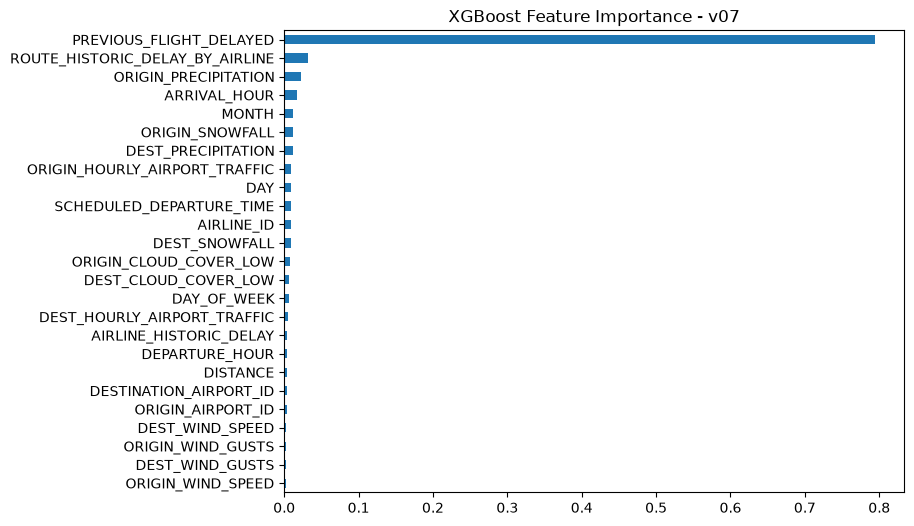

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)
print(importances)

importances.plot(kind='barh', figsize=(8,6))
plt.title('XGBoost Feature Importance - v07')
plt.gca().invert_yaxis()
plt.show()

In [29]:
weak_features = ['DEST_WIND_SPEED', 'ORIGIN_WIND_GUSTS', 'DEST_WIND_GUSTS', 
                  'ORIGIN_WIND_SPEED', 'DEPARTURE_HOUR']

X_train_reduced = X_train.drop(columns=weak_features)
X_test_reduced = X_test.drop(columns=weak_features)

In [30]:
from xgboost import XGBClassifier
import time

print("Initializing XGBoost Classifier...")
# We use standard default parameters to establish a strong baseline
model_reduced = XGBClassifier(
    random_state=42, 
    eval_metric='logloss' # Tells the model how to measure its own errors during training
)

print("Training the model on 80% of the data. Please wait...")
start_time = time.time()

# This single line is where the actual math and "learning" happens
model_reduced.fit(X_train_reduced, y_train)

end_time = time.time()
print(f"Success! Training complete in {round(end_time - start_time, 2)} seconds.")

Initializing XGBoost Classifier...
Training the model on 80% of the data. Please wait...
Success! Training complete in 13.54 seconds.


In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import joblib

print("Evaluating model on the hidden test data...")

# 1. Ask the model to make predictions
y_pred_reduced = model_reduced.predict(X_test_reduced)

# 2. Print out the KPI metrics
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_reduced))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_reduced))

# 3. Export the trained model to your hard drive
model_filename = 'xgboost_delay_model_reduced_v07_v00.joblib'
joblib.dump(model_reduced, model_filename)

print(f"\nBoom! Model fully trained, evaluated, and saved locally as: {model_filename}")

Evaluating model on the hidden test data...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.96      0.92    942478
           1       0.71      0.41      0.52    204108

    accuracy                           0.86   1146586
   macro avg       0.79      0.69      0.72   1146586
weighted avg       0.85      0.86      0.85   1146586

--- Confusion Matrix ---
[[907616  34862]
 [120539  83569]]

Boom! Model fully trained, evaluated, and saved locally as: xgboost_delay_model_reduced_v07_v00.joblib


PREVIOUS_FLIGHT_DELAYED            0.799615
ROUTE_HISTORIC_DELAY_BY_AIRLINE    0.033241
ORIGIN_PRECIPITATION               0.023442
ARRIVAL_HOUR                       0.018112
DEST_PRECIPITATION                 0.012405
ORIGIN_SNOWFALL                    0.011788
MONTH                              0.011634
ORIGIN_HOURLY_AIRPORT_TRAFFIC      0.010230
AIRLINE_ID                         0.009361
DAY                                0.009321
DEST_SNOWFALL                      0.008906
SCHEDULED_DEPARTURE_TIME           0.008828
ORIGIN_CLOUD_COVER_LOW             0.008495
DEST_CLOUD_COVER_LOW               0.006877
DEST_HOURLY_AIRPORT_TRAFFIC        0.005580
DAY_OF_WEEK                        0.005290
DISTANCE                           0.004385
DESTINATION_AIRPORT_ID             0.004382
AIRLINE_HISTORIC_DELAY             0.004237
ORIGIN_AIRPORT_ID                  0.003871
dtype: float32


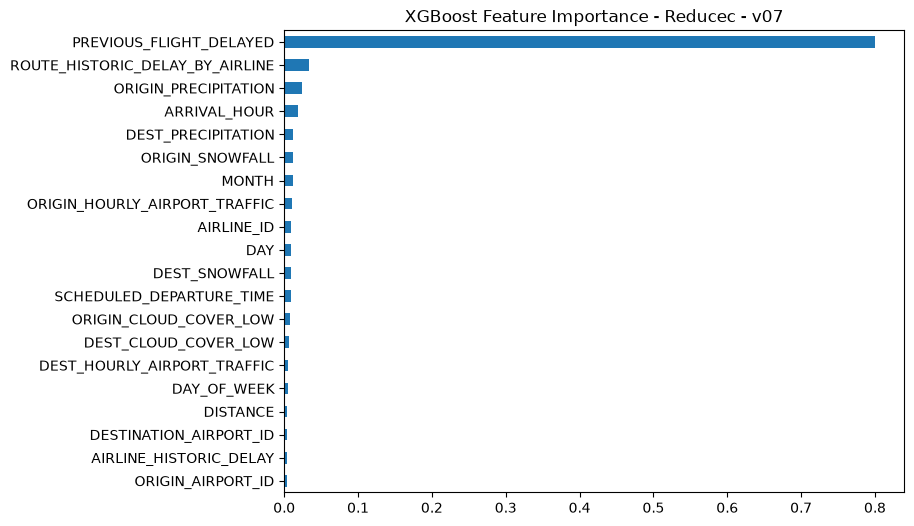

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(model_reduced.feature_importances_, index=X_train_reduced.columns)
importances = importances.sort_values(ascending=False)
print(importances)

importances.plot(kind='barh', figsize=(8,6))
plt.title('XGBoost Feature Importance - Reducec - v07')
plt.gca().invert_yaxis()
plt.show()

In [8]:
from xgboost import XGBClassifier
import time

print("Calculating class imbalance...")
# Count the 0s (On Time) and divide by the 1s (Delayed)
# Based on your confusion matrix, this will be roughly 4.6
imbalance_ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"Imbalance Ratio: {round(imbalance_ratio, 2)} to 1")

print("\nInitializing Tuned XGBoost Classifier...")
model = XGBClassifier(
    random_state=42, 
    eval_metric='logloss',
    scale_pos_weight=imbalance_ratio  # <-- The magic parameter
)

print("Training the model. Please wait...")
start_time = time.time()
model.fit(X_train, y_train)
end_time = time.time()

print(f"Success! Training complete in {round(end_time - start_time, 2)} seconds.")

Calculating class imbalance...
Imbalance Ratio: 4.63 to 1

Initializing Tuned XGBoost Classifier...
Training the model. Please wait...
Success! Training complete in 16.01 seconds.


In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import joblib

print("Evaluating model on the hidden test data...")

# 1. Ask the model to make predictions
y_pred = model.predict(X_test)

# 2. Print out the KPI metrics
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

# 3. Export the trained model to your hard drive
model_filename = 'xgboost_delay_model_07_v01.joblib'
joblib.dump(model, model_filename)

print(f"\nBoom! Model fully trained, evaluated, and saved locally as: {model_filename}")

Evaluating model on the hidden test data...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.83      0.87    942478
           1       0.45      0.65      0.53    204108

    accuracy                           0.80   1146586
   macro avg       0.68      0.74      0.70   1146586
weighted avg       0.83      0.80      0.81   1146586

--- Confusion Matrix ---
[[782183 160295]
 [ 71380 132728]]

Boom! Model fully trained, evaluated, and saved locally as: xgboost_delay_model_07_v01.joblib


PREVIOUS_FLIGHT_DELAYED            0.825812
ROUTE_HISTORIC_DELAY_BY_AIRLINE    0.028887
ORIGIN_PRECIPITATION               0.018642
ARRIVAL_HOUR                       0.016955
ORIGIN_SNOWFALL                    0.011634
DEST_PRECIPITATION                 0.010353
MONTH                              0.010036
DEST_SNOWFALL                      0.008121
SCHEDULED_DEPARTURE_TIME           0.007813
ORIGIN_HOURLY_AIRPORT_TRAFFIC      0.007129
DEST_CLOUD_COVER_LOW               0.007016
DAY                                0.006854
ORIGIN_CLOUD_COVER_LOW             0.006259
AIRLINE_ID                         0.005322
DISTANCE                           0.003743
AIRLINE_HISTORIC_DELAY             0.003727
DAY_OF_WEEK                        0.003676
DEST_HOURLY_AIRPORT_TRAFFIC        0.003535
DESTINATION_AIRPORT_ID             0.003340
ORIGIN_AIRPORT_ID                  0.002947
ORIGIN_WIND_GUSTS                  0.002274
DEST_WIND_GUSTS                    0.001866
DEST_WIND_SPEED                 

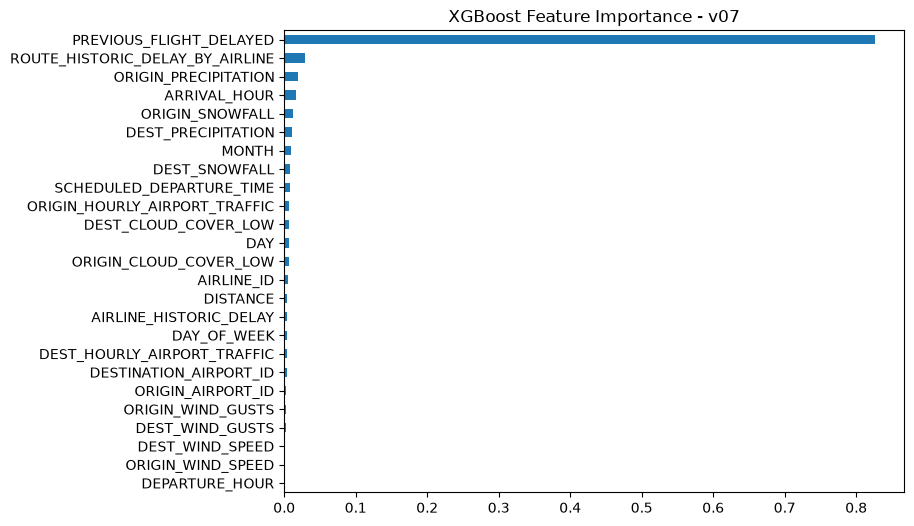

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)
print(importances)

importances.plot(kind='barh', figsize=(8,6))
plt.title('XGBoost Feature Importance - v07')
plt.gca().invert_yaxis()
plt.show()

In [33]:
weak_features = ['DEST_WIND_SPEED', 'ORIGIN_WIND_GUSTS', 'DEST_WIND_GUSTS', 
                  'ORIGIN_WIND_SPEED', 'DEPARTURE_HOUR']

X_train_reduced = X_train.drop(columns=weak_features)
X_test_reduced = X_test.drop(columns=weak_features)

In [34]:
from xgboost import XGBClassifier
import time

print("Calculating class imbalance...")
# Count the 0s (On Time) and divide by the 1s (Delayed)
# Based on your confusion matrix, this will be roughly 4.6
imbalance_ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"Imbalance Ratio: {round(imbalance_ratio, 2)} to 1")

print("\nInitializing Tuned XGBoost Classifier...")
model_reduced = XGBClassifier(
    random_state=42, 
    eval_metric='logloss',
    scale_pos_weight=imbalance_ratio  # <-- The magic parameter
)

print("Training the model. Please wait...")
start_time = time.time()
model_reduced.fit(X_train_reduced, y_train)
end_time = time.time()

print(f"Success! Training complete in {round(end_time - start_time, 2)} seconds.")

Calculating class imbalance...
Imbalance Ratio: 4.63 to 1

Initializing Tuned XGBoost Classifier...
Training the model. Please wait...
Success! Training complete in 13.46 seconds.


In [35]:
from sklearn.metrics import classification_report, confusion_matrix
import joblib

print("Evaluating model on the hidden test data...")

# 1. Ask the model to make predictions
y_pred_reduced = model_reduced.predict(X_test_reduced)

# 2. Print out the KPI metrics
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_reduced))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_reduced))

# 3. Export the trained model to your hard drive
model_filename = 'xgboost_delay_model_reduced_07_v01.joblib'
joblib.dump(model_reduced, model_filename)

print(f"\nBoom! Model fully trained, evaluated, and saved locally as: {model_filename}")

Evaluating model on the hidden test data...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.83      0.87    942478
           1       0.45      0.65      0.53    204108

    accuracy                           0.80   1146586
   macro avg       0.68      0.74      0.70   1146586
weighted avg       0.83      0.80      0.81   1146586

--- Confusion Matrix ---
[[781970 160508]
 [ 71419 132689]]

Boom! Model fully trained, evaluated, and saved locally as: xgboost_delay_model_reduced_07_v01.joblib


PREVIOUS_FLIGHT_DELAYED            0.816844
ROUTE_HISTORIC_DELAY_BY_AIRLINE    0.031139
ORIGIN_PRECIPITATION               0.019231
ARRIVAL_HOUR                       0.017438
ORIGIN_SNOWFALL                    0.015222
DEST_PRECIPITATION                 0.011529
MONTH                              0.011107
DEST_SNOWFALL                      0.009812
ORIGIN_HOURLY_AIRPORT_TRAFFIC      0.008111
SCHEDULED_DEPARTURE_TIME           0.007755
ORIGIN_CLOUD_COVER_LOW             0.007593
DAY                                0.007304
DEST_CLOUD_COVER_LOW               0.007204
AIRLINE_ID                         0.006007
DAY_OF_WEEK                        0.004587
DISTANCE                           0.004391
DEST_HOURLY_AIRPORT_TRAFFIC        0.004095
AIRLINE_HISTORIC_DELAY             0.003924
DESTINATION_AIRPORT_ID             0.003562
ORIGIN_AIRPORT_ID                  0.003144
dtype: float32


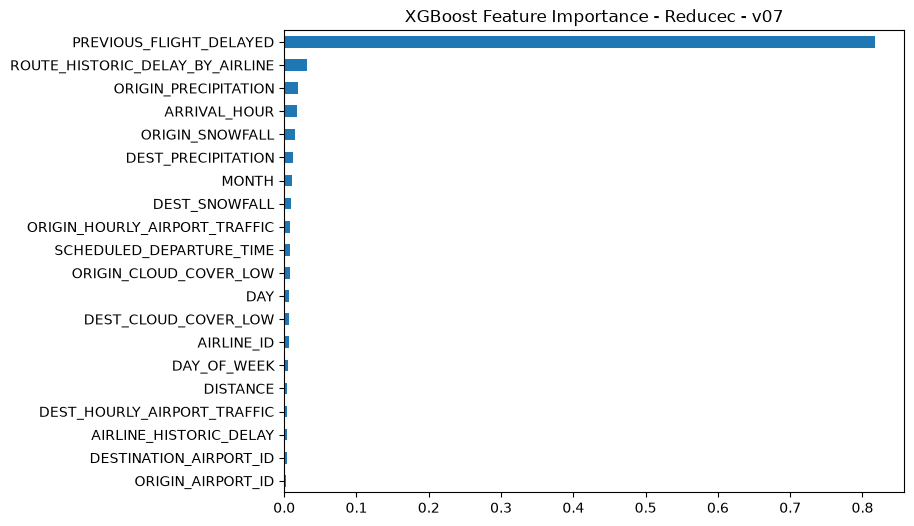

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(model_reduced.feature_importances_, index=X_train_reduced.columns)
importances = importances.sort_values(ascending=False)
print(importances)

importances.plot(kind='barh', figsize=(8,6))
plt.title('XGBoost Feature Importance - Reducec - v07')
plt.gca().invert_yaxis()
plt.show()

In [11]:
from xgboost import XGBClassifier
import time

print("\nInitializing Tuned XGBoost Classifier...")
model = XGBClassifier(
    random_state=42, 
    eval_metric='logloss',
    max_depth = 3,
    learning_rate = 0.01
)

print("Training the model. Please wait...")
start_time = time.time()
model.fit(X_train, y_train)
end_time = time.time()

print(f"Success! Training complete in {round(end_time - start_time, 2)} seconds.")


Initializing Tuned XGBoost Classifier...
Training the model. Please wait...
Success! Training complete in 11.33 seconds.


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import joblib

print("Evaluating model on the hidden test data...")

# 1. Ask the model to make predictions
y_pred = model.predict(X_test)

# 2. Print out the KPI metrics
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

# 3. Export the trained model to your hard drive
model_filename = 'xgboost_delay_model_v07_v02.joblib'
joblib.dump(model, model_filename)

print(f"\nBoom! Model fully trained, evaluated, and saved locally as: {model_filename}")

Evaluating model on the hidden test data...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.99      0.91    942478
           1       0.76      0.16      0.26    204108

    accuracy                           0.84   1146586
   macro avg       0.80      0.57      0.59   1146586
weighted avg       0.83      0.84      0.80   1146586

--- Confusion Matrix ---
[[932397  10081]
 [171984  32124]]

Boom! Model fully trained, evaluated, and saved locally as: xgboost_delay_model_v07_v02.joblib


PREVIOUS_FLIGHT_DELAYED            0.892633
ROUTE_HISTORIC_DELAY_BY_AIRLINE    0.031375
ARRIVAL_HOUR                       0.018368
SCHEDULED_DEPARTURE_TIME           0.015591
ORIGIN_PRECIPITATION               0.009201
ORIGIN_HOURLY_AIRPORT_TRAFFIC      0.007170
AIRLINE_HISTORIC_DELAY             0.006967
ORIGIN_SNOWFALL                    0.006925
DEST_HOURLY_AIRPORT_TRAFFIC        0.005816
AIRLINE_ID                         0.004621
ORIGIN_CLOUD_COVER_LOW             0.001333
DESTINATION_AIRPORT_ID             0.000000
DISTANCE                           0.000000
DAY                                0.000000
DAY_OF_WEEK                        0.000000
MONTH                              0.000000
ORIGIN_AIRPORT_ID                  0.000000
DEPARTURE_HOUR                     0.000000
ORIGIN_WIND_SPEED                  0.000000
ORIGIN_WIND_GUSTS                  0.000000
DEST_PRECIPITATION                 0.000000
DEST_WIND_GUSTS                    0.000000
DEST_WIND_SPEED                 

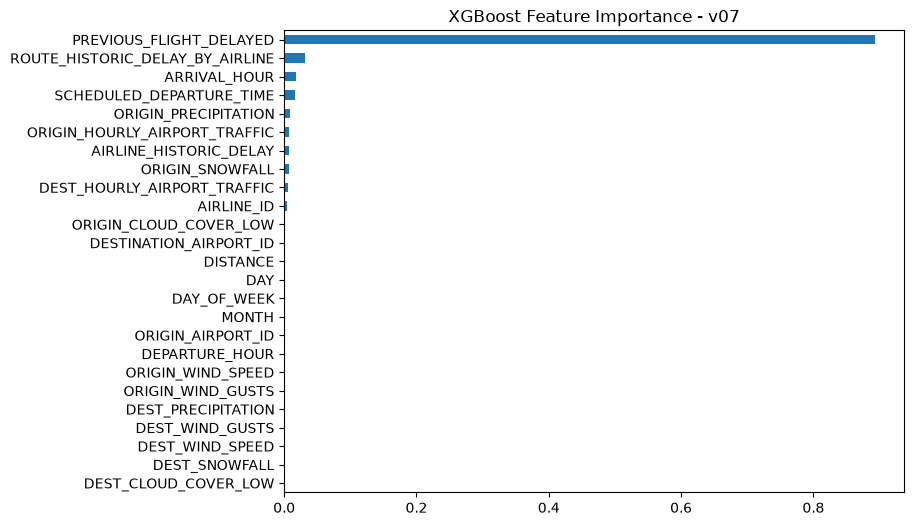

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)
print(importances)

importances.plot(kind='barh', figsize=(8,6))
plt.title('XGBoost Feature Importance - v07')
plt.gca().invert_yaxis()
plt.show()